In [12]:
import stpsf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [22]:
filter_list = ['F070LP', 'F100LP', 'F170LP', 'F290LP']

In [25]:
plt.figure(figsize=(48, 48))
ns = stpsf.NIRSpec()

ns.filter = 'F170LP'
ns.image_mask='MSA all open'
msapsf = ns.calc_psf(monochromatic=2e-6, oversample=8)


<Figure size 4800x4800 with 0 Axes>

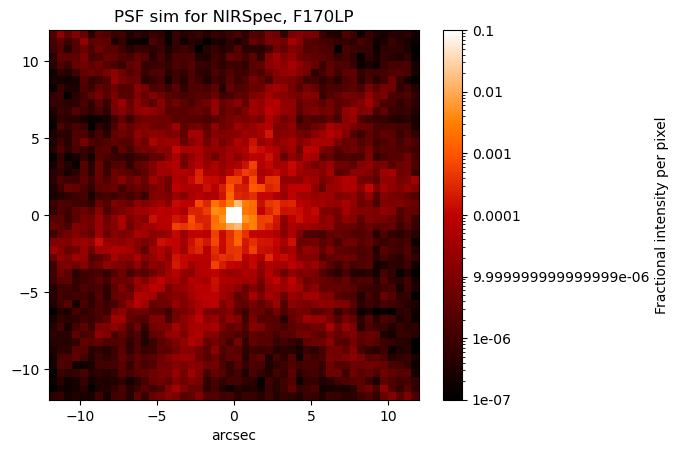

In [28]:
stpsf.display_psf(msapsf, ext='DET_SAMP',pixelscale=0.5)

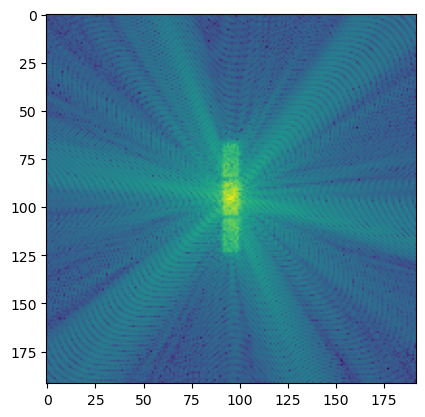

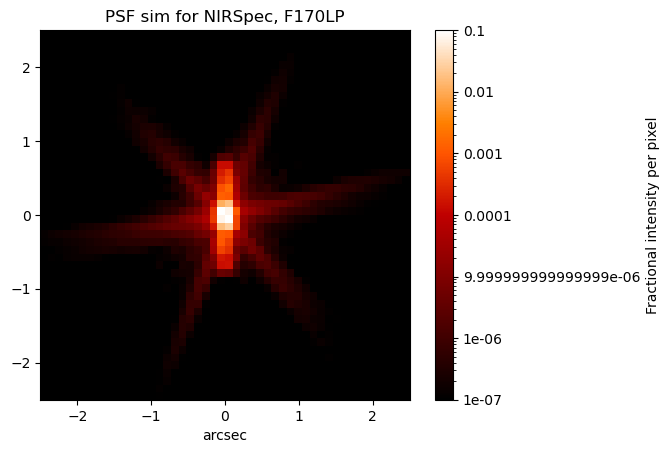

In [31]:
ns = stpsf.NIRSpec()

ns.filter = 'F170LP'
ns.image_mask='Three adjacent MSA open shutters'

msapsf = ns.calc_psf(monochromatic=4.863000000000001e-07, oversample=4)
data=msapsf[0].data
plt.imshow(data, cmap='viridis', norm='log',resample=0.5)
plt.show()
stpsf.display_psf(msapsf, ext='DET_SAMP')

正在初始化 NIRSpec 仪器...
仪器: NIRSpec
滤光片: F170LP

正在计算 4863.0 Angstrom 处的 PSF...
正在计算 6563.0 Angstrom 处的 PSF...

PSF 计算完成。
正在生成图像...


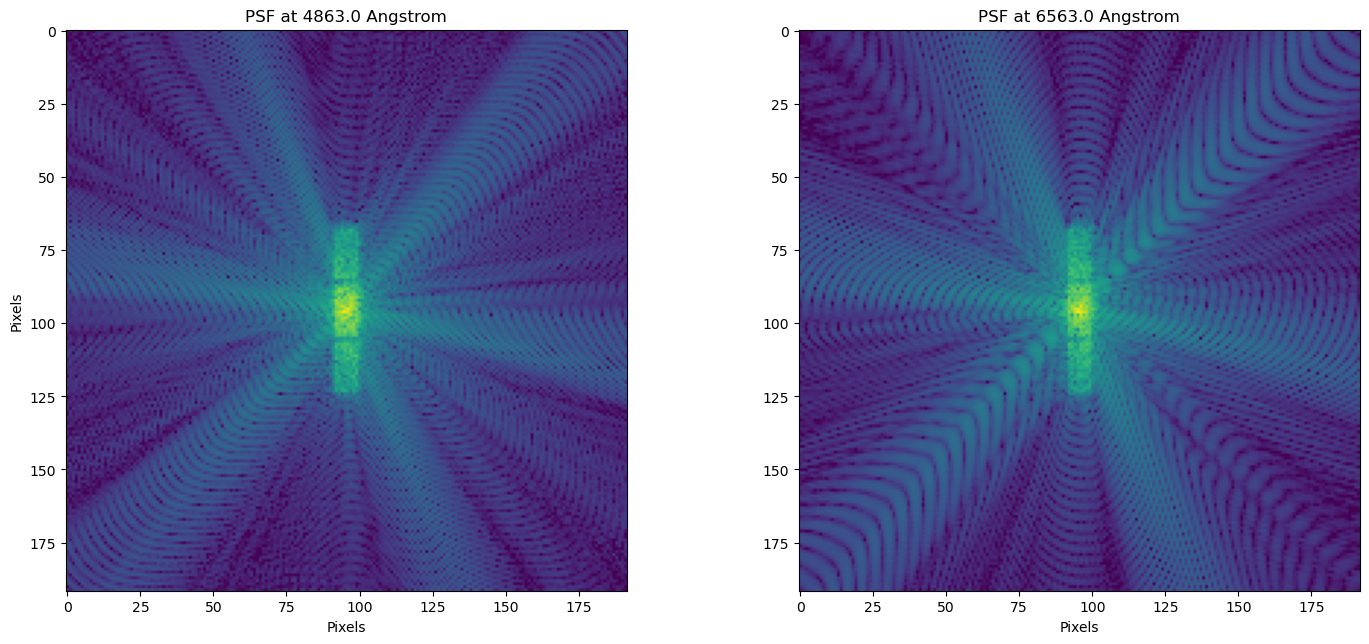

In [32]:
import stpsf
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
import numpy as np
import warnings

# 忽略 astropy IERS 数据可能过时的警告
warnings.filterwarnings('ignore', category=UserWarning, message='IERS data is out of date.')

# --- 1. 初始化仪器并进行设置 ---

print("正在初始化 NIRSpec 仪器...")
nirspec = stpsf.NIRSpec()
nirspec.filter = 'F170LP'
nirspec.image_mask='Three adjacent MSA open shutters'
#nirspec.apername = 'MSA_3_ADJ' # 使用 apername 是正确的做法

print(f"仪器: {nirspec.name}")
print(f"滤光片: {nirspec.filter}")
#print(f"孔径: {nirspec.apername}")

# --- 2. 定义波长并进行单位转换 ---

wavelength1_A = 4863 * u.AA
wavelength2_A = 6563 * u.AA
wavelength1_m = wavelength1_A.to(u.m).value
wavelength2_m = wavelength2_A.to(u.m).value

# --- 3. 计算两个波长下的 PSF ---

OVERSAMPLE = 4

print(f"\n正在计算 {wavelength1_A} 处的 PSF...")
psf_4863_hdu = nirspec.calc_psf(monochromatic=wavelength1_m, oversample=OVERSAMPLE)
psf_4863_data = psf_4863_hdu[0].data

print(f"正在计算 {wavelength2_A} 处的 PSF...")
psf_6563_hdu = nirspec.calc_psf(monochromatic=wavelength2_m, oversample=OVERSAMPLE)
psf_6563_data = psf_6563_hdu[0].data

print("\nPSF 计算完成。")

# --- 4. 绘制结果 (使用统一的颜色轴) ---

print("正在生成图像...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
#fig.suptitle(f'NIRSpec PSF Simulation with {nirspec.apername} Aperture', fontsize=16)

# *** 新增代码: 确定全局的颜色范围 ***
# 找到两个 PSF 强度的全局最大值
vmax = max(psf_4863_data.max(), psf_6563_data.max())
# 为对数坐标找到一个合适的全局最小值 (避免取到0)
# 我们选择一个比最大值小很多但大于0的数，例如最大值的百万分之一
vmin = vmax / 1e10

# 创建一个可以在两个图之间共享的对数归一化实例
norm = LogNorm(vmin=vmin, vmax=vmax)

# 绘制 4863 Angstrom 的 PSF
# 在 imshow 中传入共享的 norm 参数
im1 = ax1.imshow(psf_4863_data, cmap='viridis', norm=norm)
ax1.set_title(f'PSF at {wavelength1_A}')
ax1.set_xlabel('Pixels')
ax1.set_ylabel('Pixels')


# 绘制 6563 Angstrom 的 PSF
# 在 imshow 中传入完全相同的 norm 参数
im2 = ax2.imshow(psf_6563_data, cmap='viridis', norm=norm)
ax2.set_title(f'PSF at {wavelength2_A}')
ax2.set_xlabel('Pixels')

# 在图像右侧添加一个共享的颜色条
#fig.colorbar(im2, ax=[ax1, ax2], orientation='vertical', label='Intensity (Log Scale)', pad=0.02)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

正在初始化 NIRSpec 仪器...
仪器: NIRSpec
滤光片: F170LP

正在计算 4863.0 Angstrom 处的 PSF...
正在计算 6563.0 Angstrom 处的 PSF...

PSF 计算完成。
正在生成图像...


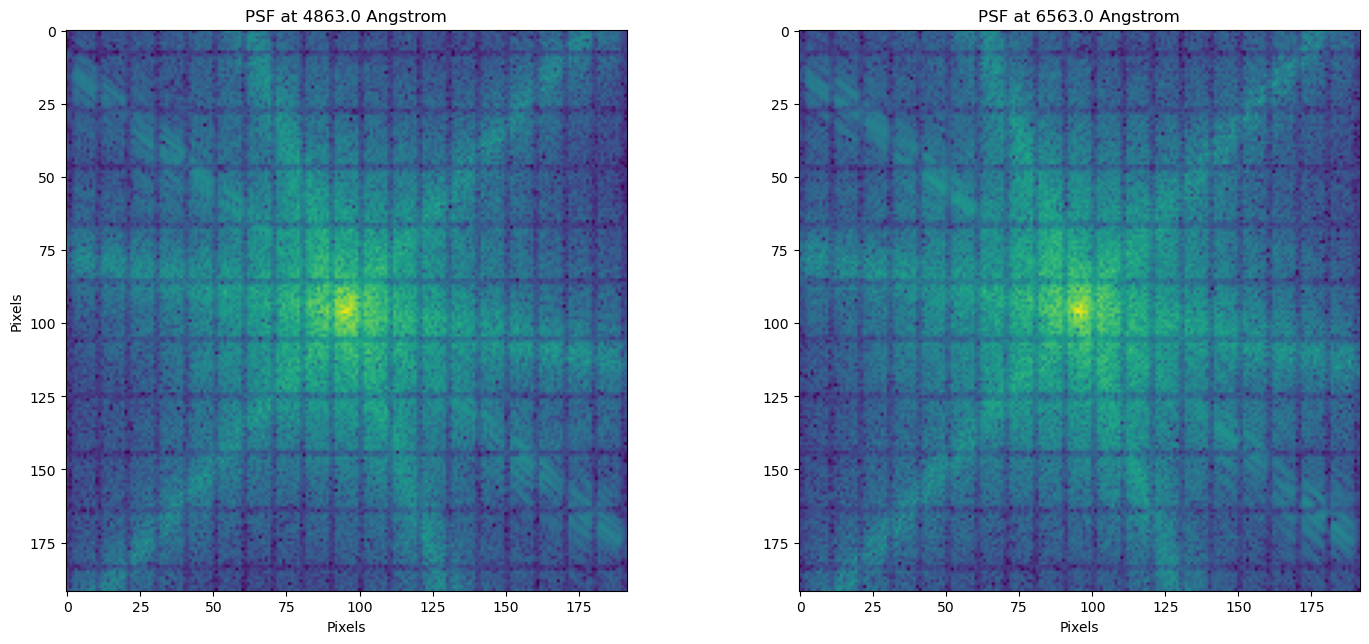

In [33]:
import stpsf
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
import numpy as np
import warnings

# 忽略 astropy IERS 数据可能过时的警告
warnings.filterwarnings('ignore', category=UserWarning, message='IERS data is out of date.')

# --- 1. 初始化仪器并进行设置 ---

print("正在初始化 NIRSpec 仪器...")
nirspec = stpsf.NIRSpec()
nirspec.filter = 'F170LP'
nirspec.image_mask='MSA all open'
#nirspec.apername = 'MSA_3_ADJ' # 使用 apername 是正确的做法

print(f"仪器: {nirspec.name}")
print(f"滤光片: {nirspec.filter}")
#print(f"孔径: {nirspec.apername}")

# --- 2. 定义波长并进行单位转换 ---

wavelength1_A = 4863 * u.AA
wavelength2_A = 6563 * u.AA
wavelength1_m = wavelength1_A.to(u.m).value
wavelength2_m = wavelength2_A.to(u.m).value

# --- 3. 计算两个波长下的 PSF ---

OVERSAMPLE = 4

print(f"\n正在计算 {wavelength1_A} 处的 PSF...")
psf_4863_hdu = nirspec.calc_psf(monochromatic=wavelength1_m, oversample=OVERSAMPLE)
psf_4863_data = psf_4863_hdu[0].data

print(f"正在计算 {wavelength2_A} 处的 PSF...")
psf_6563_hdu = nirspec.calc_psf(monochromatic=wavelength2_m, oversample=OVERSAMPLE)
psf_6563_data = psf_6563_hdu[0].data

print("\nPSF 计算完成。")

# --- 4. 绘制结果 (使用统一的颜色轴) ---

print("正在生成图像...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
#fig.suptitle(f'NIRSpec PSF Simulation with {nirspec.apername} Aperture', fontsize=16)

# *** 新增代码: 确定全局的颜色范围 ***
# 找到两个 PSF 强度的全局最大值
vmax = max(psf_4863_data.max(), psf_6563_data.max())
# 为对数坐标找到一个合适的全局最小值 (避免取到0)
# 我们选择一个比最大值小很多但大于0的数，例如最大值的百万分之一
vmin = vmax / 1e10

# 创建一个可以在两个图之间共享的对数归一化实例
norm = LogNorm(vmin=vmin, vmax=vmax)

# 绘制 4863 Angstrom 的 PSF
# 在 imshow 中传入共享的 norm 参数
im1 = ax1.imshow(psf_4863_data, cmap='viridis', norm=norm)
ax1.set_title(f'PSF at {wavelength1_A}')
ax1.set_xlabel('Pixels')
ax1.set_ylabel('Pixels')


# 绘制 6563 Angstrom 的 PSF
# 在 imshow 中传入完全相同的 norm 参数
im2 = ax2.imshow(psf_6563_data, cmap='viridis', norm=norm)
ax2.set_title(f'PSF at {wavelength2_A}')
ax2.set_xlabel('Pixels')

# 在图像右侧添加一个共享的颜色条
#fig.colorbar(im2, ax=[ax1, ax2], orientation='vertical', label='Intensity (Log Scale)', pad=0.02)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

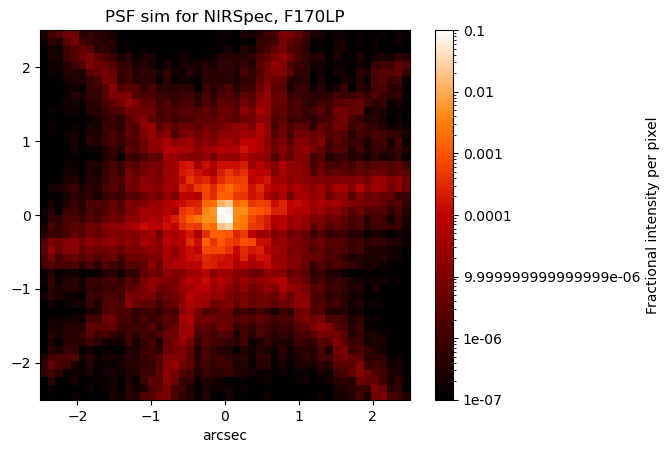

In [35]:
stpsf.display_psf(psf_4863_hdu, ext='DET_SAMP')


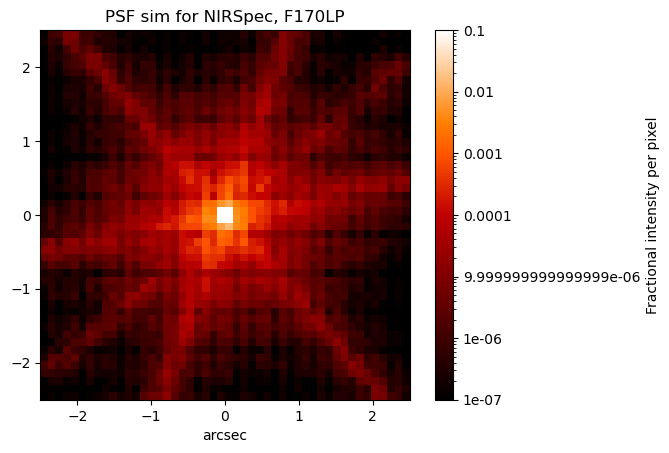

In [36]:
stpsf.display_psf(psf_6563_hdu, ext='DET_SAMP')

In [ ]:
1